# 웹캠 실시간 객체 탐지

객체 탐지(Object Detection)는 이미지 안에 어떤 사물이 있는지 분류하고, 각 사물이 있는 위치를 bounding box로 함께 찾는 작업이다. 화면 전체에 하나의 이름만 붙이는 이미지 분류와 달리 한 화면의 사람, 컵, 의자, 노트북을 각각 구분할 수 있다.

웹캠은 연속된 이미지를 빠르게 전달하므로 각 이미지를 YOLO 모델에 반복 입력하면 실시간 객체 탐지가 된다. 이 기술은 재고 확인, 안전 모니터링, 반려동물 관찰, 매장 분석과 접근성 보조 기능 등에 사용할 수 있다.

이 노트북에서는 로컬 PC의 웹캠에서 한 프레임을 먼저 확인하고, YOLO26 경량 모델로 사물명·위치·신뢰도를 추출한 뒤 별도 창에서 실시간 탐지를 실행한다.

## 객체 탐지의 입력과 출력

웹캠은 동영상 한 덩어리를 전달하는 것이 아니라 시간 순서대로 여러 장의 frame을 전달한다. 모델은 현재 frame 한 장을 입력받아 사물마다 class, confidence, bounding box를 반환하고, 다음 frame에서 같은 과정을 반복한다.

```mermaid
flowchart LR
    A[웹캠] --> B[현재 frame 읽기]
    B --> C[YOLO 객체 탐지]
    C --> D[class와 confidence]
    C --> E[bounding box 좌표]
    D --> F[탐지 결과 그리기]
    E --> F
    F --> G[화면 표시]
    G --> B
```

- **Frame**: 동영상을 구성하는 한 장의 이미지이다.
- **FPS(Frames Per Second)**: 1초 동안 처리하거나 표시하는 frame 수이다.
- **Class**: 모델이 예측한 사물 종류이며 `person`, `cup`, `laptop`과 같은 이름으로 표시된다.
- **Confidence**: 해당 class 예측을 모델이 얼마나 확신하는지 나타내는 0~1 사이의 점수이다.
- **Bounding box**: 사물의 위치를 `[x_min, y_min, x_max, y_max]` 네 좌표로 나타낸 사각형이다.
- **Inference**: 학습이 끝난 모델에 새로운 입력을 넣어 결과를 예측하는 과정이다.

이미지 분류는 화면 전체의 대표 class가 필요할 때 사용하고, 객체 탐지는 화면 안의 여러 사물과 각 위치가 필요할 때 사용한다. 이 실습의 출력은 후자인 사물별 class·confidence·bounding box이다.

## 실행 환경과 카메라 사용 범위

이 실습은 웹캠이 연결된 **로컬 PC의 PyCharm 또는 Jupyter 커널**에서 실행한다. RunPod나 Colab에서 `VideoCapture(0)`을 실행하면 학생 PC가 아니라 원격 서버의 카메라를 찾으므로 같은 코드로는 웹캠에 접근할 수 없다.

실시간 결과는 노트북 출력 영역이 아니라 OpenCV가 만든 별도 창에 표시된다. 영상 창을 한 번 클릭한 뒤 `q`를 누르면 반복이 종료된다. macOS와 Windows에서 카메라가 열리지 않으면 PyCharm·Terminal·Python의 카메라 권한과 다른 앱의 카메라 사용 여부를 확인한다.

기본 실습은 frame을 파일로 저장하거나 네트워크로 전송하지 않는다. 사람을 탐지할 수는 있지만 얼굴 신원 확인, 감정·성격 추정과 같은 기능은 이 수업 범위에 포함하지 않는다.

## 실습 패키지 설치

OpenCV는 웹캠에서 frame을 읽고 별도 영상 창을 관리한다. Ultralytics는 YOLO 모델을 내려받고 추론 결과를 다루는 Python API를 제공한다.

수업 중 API 변화가 생기지 않도록 Ultralytics 8.4.135와 OpenCV 4.x 계열 4.10.0.84를 고정한다. 이 OpenCV 버전은 최신 4.x보다 구형 macOS wheel의 지원 범위가 넓고, 이 실습에서 사용하는 API는 동일하다. 설치 후 import 오류가 계속되면 커널을 한 번 재시작한다.

In [1]:
%pip install -q ultralytics==8.4.135 opencv-python==4.10.0.84

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\playdata2\miniforge3\envs\llm_env\python.exe -m pip install --upgrade pip


## 라이브러리와 실습 설정

기본 웹캠은 보통 index `0`이고, USB 카메라가 추가로 연결되어 있으면 `1` 또는 `2`일 수 있다. `CONFIDENCE_THRESHOLD`는 화면에 남길 최소 신뢰도이고, `IMAGE_SIZE`는 YOLO에 넣을 이미지의 기준 크기이다.

이 실습은 일반 PC에서도 실행할 수 있도록 가장 작은 nano 모델, 0.4 신뢰도, 480 입력 크기, CPU를 기본값으로 사용한다.

In [2]:
import time

import cv2
from IPython.display import display
from PIL import Image as PILImage
from ultralytics import YOLO

# CAMERA_INDEX는 읽을 실제 카메라 장치를 선택하며 노트북 전체에서 같은 입력을 사용한다.
CAMERA_INDEX = 0
# MODEL_ID와 아래 추론 설정은 단일 frame과 실시간 반복에 동일하게 전달된다.
MODEL_ID = "yolo26n.pt"
CONFIDENCE_THRESHOLD = 0.40
IMAGE_SIZE = 480
DEVICE = "cpu"

print({
    "camera_index": CAMERA_INDEX,
    "model": MODEL_ID,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "image_size": IMAGE_SIZE,
    "device": DEVICE,
})

WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\playdata2\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
{'camera_index': 0, 'model': 'yolo26n.pt', 'confidence_threshold': 0.4, 'image_size': 480, 'device': 'cpu'}


## YOLO26 nano 모델 준비

YOLO(You Only Look Once)는 한 번의 모델 추론으로 여러 객체의 class와 위치를 함께 예측하는 객체 탐지 모델이다. `yolo26n.pt`의 `n`은 nano를 뜻하며 같은 계열의 큰 모델보다 정확도는 낮을 수 있지만 CPU 실시간 실습에 유리하다.

이 모델은 [COCO 데이터셋의 80개 class](https://docs.ultralytics.com/datasets/detect/coco)를 학습한 가중치이다. 사람, 컵, 병, 의자, 노트북, 휴대전화 같은 일반 사물은 찾을 수 있지만 특정 상품명이나 수업 전용 물품은 별도 학습 없이 구분할 수 없다.

`YOLO(MODEL_ID)`를 처음 실행하면 모델 가중치를 자동으로 내려받는다. 모델 로딩과 최신 predict API는 [Ultralytics 공식 문서](https://docs.ultralytics.com/modes/predict)를 참고한다.

In [3]:
# YOLO는 MODEL_ID의 구조와 사전학습 가중치를 읽어 predict에 사용할 model 객체를 만든다.
model = YOLO(MODEL_ID)

# names는 class ID를 사람이 읽는 영문 사물명으로 연결하는 mapping이다.
first_ten_classes = list(model.names.items())[:10]
print({"class_count": len(model.names), "first_ten_classes": first_ten_classes})

{'class_count': 80, 'first_ten_classes': [(0, 'person'), (1, 'bicycle'), (2, 'car'), (3, 'motorcycle'), (4, 'airplane'), (5, 'bus'), (6, 'train'), (7, 'truck'), (8, 'boat'), (9, 'traffic light')]}


## 웹캠에서 한 프레임 촬영

`cv2.VideoCapture(CAMERA_INDEX)`는 지정한 카메라를 열고, `read()`는 성공 여부와 현재 frame을 반환한다. frame은 `(H, W, C)` shape의 NumPy 배열이며 각 축은 높이, 너비, 색상 채널을 의미한다.

OpenCV frame의 색상 순서는 BGR이지만 PIL과 일반 이미지 표시는 RGB를 사용한다. 따라서 화면에 표시할 때만 `cvtColor`로 BGR을 RGB로 바꾼다. 이 셀에서 한 장을 정상적으로 확인한 뒤에만 실시간 반복으로 진행한다. `read_required_frame()`은 읽기 실패를 명확한 오류로 바꾸고, `try-finally`는 성공 여부와 관계없이 카메라를 해제한다.

{'shape_hwc': (480, 640, 3), 'dtype': 'uint8'}


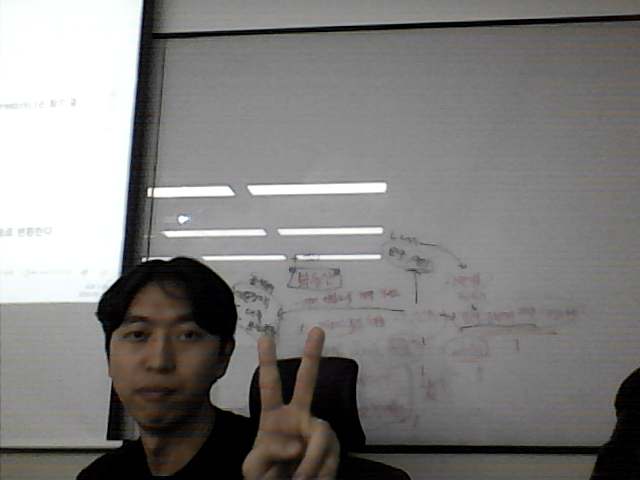

In [5]:
# read_required_frame은 한 장을 읽고 실패하면 카메라 설정을 확인할 수 있도록 명확한 오류를 발생시킨다.
def read_required_frame(camera):
    success, frame = camera.read()
    if not success:
        raise RuntimeError("웹캠 frame을 읽지 못했다. 카메라 권한과 CAMERA_INDEX를 확인한다.")
    return frame

# VideoCapture는 CAMERA_INDEX의 카메라 스트림을 열고, finally는 오류가 나도 장치를 반환한다.
camera = cv2.VideoCapture(CAMERA_INDEX)
try:
    frame_bgr = read_required_frame(camera)
finally:
    camera.release()

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
print({"shape_hwc": frame_bgr.shape, "dtype": str(frame_bgr.dtype)})
display(PILImage.fromarray(frame_rgb))

## 한 프레임에서 객체 탐지

먼저 저장해 둔 `frame_bgr` 한 장을 YOLO에 넣어 카메라 반복과 모델 추론을 분리해서 확인한다. `predict()`는 탐지 결과 목록을 반환하며 입력이 한 장이므로 첫 번째 `Results` 객체를 사용한다.

- `source`: 탐지할 BGR frame 배열이다.
- `conf`: 이 값보다 낮은 confidence의 탐지를 제거한다.
- `imgsz`: 추론 전에 조정할 기준 이미지 크기이며 작을수록 빠르지만 작은 객체를 놓칠 수 있다.
- `device`: 모델 연산을 실행할 장치이며 기본 실습은 `cpu`이다.
- `verbose`: frame마다 출력되는 상세 로그를 끄기 위해 `False`를 사용한다.

`result.plot()`은 bounding box와 label이 그려진 BGR 배열을 반환한다. 표시할 때는 앞 셀과 같이 RGB로 변환한다.

{'detected_object_count': 2}


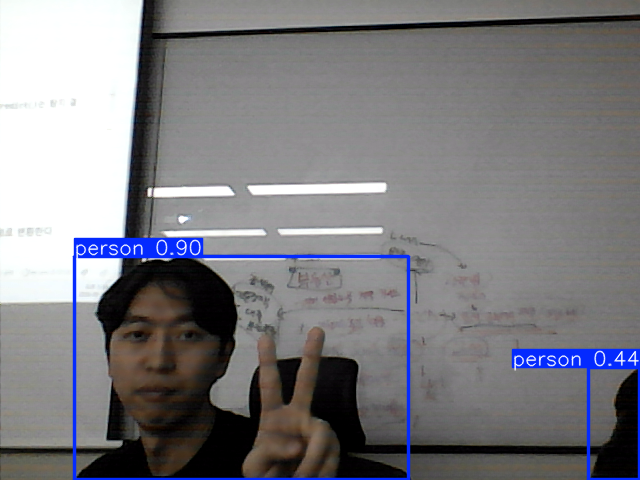

In [6]:
# source의 frame 픽셀을 imgsz 기준으로 전처리하고 DEVICE에서 객체 탐지를 실행한다.
# conf 기준을 통과한 box만 Results 객체에 남아 시각화와 구조화에 사용된다.
result = model.predict(
    source=frame_bgr,
    conf=CONFIDENCE_THRESHOLD,
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    verbose=False,
)[0]

# plot의 출력은 OpenCV와 같은 BGR이므로 노트북 표시 전에 RGB로 변환한다.
annotated_bgr = result.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

print({"detected_object_count": len(result.boxes)})
display(PILImage.fromarray(annotated_rgb))

## 탐지 결과의 이름·신뢰도·좌표 확인

시각화만 보면 후속 프로그램에서 사용할 값을 알기 어렵다. `result.boxes.cls`, `conf`, `xyxy`에는 각각 class ID, confidence, bounding box 좌표가 같은 순서로 들어 있다.

예를 들어 세 목록의 0번 값은 모두 첫 번째 사물에 대한 정보이다. class ID는 `result.names` mapping으로 영문 사물명으로 바꾸고, Tensor 값은 CPU list로 변환해 Python dictionary에 저장한다. 이 dictionary는 이후 개수 세기, 경고 조건, 로그 저장 등에 사용할 수 있다.

In [7]:
# GPU에서도 같은 후처리를 할 수 있도록 세 Tensor를 CPU의 Python list로 변환한다.
class_ids = result.boxes.cls.cpu().tolist()
confidence_scores = result.boxes.conf.cpu().tolist()
bounding_boxes = result.boxes.xyxy.cpu().tolist()

detections = []
# 같은 인덱스의 class_id, confidence, bbox는 한 객체의 예측 결과이다.
for class_id, confidence, bbox in zip(class_ids, confidence_scores, bounding_boxes):
    detection = {
        "class_id": int(class_id),
        "class_name": result.names[int(class_id)],
        "confidence": round(float(confidence), 4),
        "bbox_xyxy": [round(value, 1) for value in bbox],
    }
    detections.append(detection)

print({"count": len(detections), "detections": detections})

{'count': 2, 'detections': [{'class_id': 0, 'class_name': 'person', 'confidence': 0.9005, 'bbox_xyxy': [74.4, 256.7, 408.7, 479.6]}, {'class_id': 0, 'class_name': 'person', 'confidence': 0.4406, 'bbox_xyxy': [588.8, 367.1, 639.6, 479.0]}]}


## 별도 창에서 실시간 객체 탐지

실시간 탐지는 `카메라 frame 읽기 → YOLO 추론 → 결과 그리기 → 화면 표시`를 반복한다. `model.predict()`와 `result.plot()`에 걸린 시간의 역수로 **처리 FPS**를 계산해 영상 왼쪽 위에 표시한다. 이 값은 카메라 읽기, 창 표시, 키 입력 대기까지 포함한 전체 FPS와는 다르다.

`cv2.imshow()`는 PyCharm 노트북 셀 안이 아니라 별도의 `YOLO Webcam` 창을 연다. 영상 창을 클릭한 뒤 `q`를 누르면 반복 조건이 끝난다. `finally` 블록은 정상 종료나 실행 중 오류와 관계없이 카메라와 영상 창을 해제해 다음 실행에서 웹캠이 잠기는 문제를 줄인다.

In [8]:
camera = cv2.VideoCapture(CAMERA_INDEX)
pressed_key = -1

try:
    # q가 입력될 때까지 현재 frame만 읽고 처리하므로 전체 영상을 메모리에 쌓지 않는다.
    while pressed_key != ord("q"):
        live_frame = read_required_frame(camera)

        started_at = time.perf_counter()
        live_result = model.predict(
            source=live_frame,
            conf=CONFIDENCE_THRESHOLD,
            imgsz=IMAGE_SIZE,
            device=DEVICE,
            verbose=False,
        )[0]
        annotated_frame = live_result.plot()

        # 현재 frame 한 장의 추론·시각화 시간으로 처리 FPS를 계산한다.
        elapsed_seconds = max(time.perf_counter() - started_at, 1e-9)
        processing_fps = 1.0 / elapsed_seconds
        cv2.putText(
            annotated_frame,
            f"Processing FPS: {processing_fps:.1f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2,
        )

        cv2.imshow("YOLO Webcam", annotated_frame)
        pressed_key = cv2.waitKey(1) & 0xFF
finally:
    camera.release()
    cv2.destroyAllWindows()

KeyboardInterrupt: 

## 속도와 탐지 품질 조절

실시간 객체 탐지는 정확도만 높다고 좋은 것이 아니라 화면이 끊기지 않을 정도의 처리 속도도 필요하다. 다음 순서로 한 항목씩 바꾸면서 FPS와 탐지 결과를 함께 비교한다.

1. `IMAGE_SIZE`를 480에서 320으로 줄이면 빨라지지만 멀리 있는 작은 사물을 놓칠 수 있다.
2. `CONFIDENCE_THRESHOLD`를 높이면 잘못된 label은 줄지만 흐리거나 가려진 사물이 사라질 수 있다.
3. 사양이 충분하면 `DEVICE`를 NVIDIA GPU의 `0` 또는 Apple Silicon의 `mps`로 바꿔 속도를 비교할 수 있다.
4. 모든 frame을 처리할 필요가 없으면 2~5 FPS만 샘플링해도 사물 존재 여부를 확인하는 실습은 가능하다.

수업에서는 사람, 컵, 휴대전화처럼 COCO class에 있는 사물 3~5개를 밝기·거리·각도를 바꿔 보여 준다. confidence만 보지 말고 올바른 사물을 찾았는지, 빠뜨린 사물은 없는지, box가 실제 위치와 맞는지, FPS가 얼마나 변하는지를 함께 기록한다.

## 정리와 확장 방향

이 실습의 핵심 흐름은 `웹캠 → frame → YOLO → class·confidence·bounding box → 실시간 표시`이다. YOLO만으로 학습된 사물의 이름과 위치를 빠르게 찾을 수 있으므로 기본 객체 탐지에는 LLM이 필요하지 않다.

사전학습 모델은 COCO 80개 class 밖의 특정 제품, 부품, 강의실 전용 물품을 알지 못한다. 이런 대상을 구분하려면 직접 이미지를 수집하고 bounding box를 라벨링한 뒤 custom model을 학습해야 한다. 여러 frame에서 같은 사물을 같은 ID로 유지하려면 객체 추적을 추가한다.

화면 전체 상황을 자연어로 자세히 설명하거나 COCO에 없는 물체를 열린 질문으로 분석해야 할 때는 VLM을 선택적으로 추가할 수 있다. VLM은 YOLO보다 느리고 비용이 들 수 있으므로 모든 frame이 아니라 버튼을 누른 순간이나 몇 초 간격의 대표 frame만 보내는 방식이 적합하다.

카메라 서비스를 만들 때는 촬영 사실 고지, 저장 여부, 보관 기간, 접근 권한을 먼저 정한다. Ultralytics를 제품이나 비공개 서비스에 포함할 때는 [AGPL-3.0과 Enterprise 라이선스 조건](https://www.ultralytics.com/license)을 별도로 확인한다.